In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [30]:
import os

os.listdir()

['.config',
 'likes.csv',
 'users.csv',
 'comments.csv',
 'photo_tags.csv',
 'photos.csv',
 '.ipynb_checkpoints',
 'follows.csv',
 'tags.csv',
 'sample_data']

In [31]:
import pandas as pd

users = pd.read_csv("users.csv")
photos = pd.read_csv("photos.csv")
likes = pd.read_csv("likes.csv")
comments = pd.read_csv("comments.csv")
follows = pd.read_csv("follows.csv")
tags = pd.read_csv("tags.csv")
photo_tags = pd.read_csv("photo_tags.csv")

In [32]:
users.columns
photos.columns
likes.columns
comments.columns
follows.columns
tags.columns
photo_tags.columns

Index(['photo', 'tag ID', 'user id'], dtype='object')

In [33]:
print("USERS")
print(users.columns)

print("\nPHOTOS")
print(photos.columns)

print("\nLIKES")
print(likes.columns)

print("\nCOMMENTS")
print(comments.columns)

print("\nFOLLOWS")
print(follows.columns)

print("\nTAGS")
print(tags.columns)

print("\nPHOTO_TAGS")
print(photo_tags.columns)

USERS
Index(['id', 'name', 'created time', 'private/public', 'post count',
       'Verified status'],
      dtype='object')

PHOTOS
Index(['id', 'image link', 'user ID', 'created dat', 'Insta filter used',
       'photo type'],
      dtype='object')

LIKES
Index(['user ', 'photo', 'created time', 'following or not', 'like type'], dtype='object')

COMMENTS
Index(['id', 'comment', 'User  id', 'Photo id', 'created Timestamp',
       'posted date', 'emoji used', 'Hashtags used count'],
      dtype='object')

FOLLOWS
Index(['follower', 'followee ', 'created time', 'is follower active',
       'followee Acc status'],
      dtype='object')

TAGS
Index(['id', 'tag text', 'created time', 'location'], dtype='object')

PHOTO_TAGS
Index(['photo', 'tag ID', 'user id'], dtype='object')


In [34]:
users.info()
photos.info()
likes.info()
comments.info()
follows.info()
tags.info()
photo_tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               100 non-null    int64 
 1   name             100 non-null    object
 2   created time     100 non-null    object
 3   private/public   100 non-null    object
 4   post count       100 non-null    int64 
 5   Verified status  100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 257 non-null    int64 
 1   image link         257 non-null    object
 2   user ID            257 non-null    int64 
 3   created dat        257 non-null    object
 4   Insta filter used  257 non-null    object
 5   photo type         257 non-null    object
dtypes:

In [35]:
print(users.isnull().sum())
print(photos.isnull().sum())
print(likes.isnull().sum())
print(comments.isnull().sum())
print(follows.isnull().sum())
print(tags.isnull().sum())
print(photo_tags.isnull().sum())

id                 0
name               0
created time       0
private/public     0
post count         0
Verified status    0
dtype: int64
id                   0
image link           0
user ID              0
created dat          0
Insta filter used    0
photo type           0
dtype: int64
user                0
photo               0
created time        0
following or not    0
like type           0
dtype: int64
id                     0
comment                0
User  id               0
Photo id               0
created Timestamp      0
posted date            0
emoji used             0
Hashtags used count    0
dtype: int64
follower               0
followee               0
created time           0
is follower active     0
followee Acc status    0
dtype: int64
id              0
tag text        0
created time    0
location        0
dtype: int64
photo      0
tag ID     0
user id    0
dtype: int64


In [36]:
users.drop_duplicates(inplace=True)
photos.drop_duplicates(inplace=True)
likes.drop_duplicates(inplace=True)
comments.drop_duplicates(inplace=True)
follows.drop_duplicates(inplace=True)
tags.drop_duplicates(inplace=True)
photo_tags.drop_duplicates(inplace=True)

In [37]:
users["created time"] = pd.to_datetime(users["created time"])

photos["created dat"] = pd.to_datetime(photos["created dat"])

likes["created time"] = pd.to_datetime(likes["created time"])

comments["created Timestamp"] = pd.to_datetime(comments["created Timestamp"])

follows["created time"] = pd.to_datetime(follows["created time"])

tags["created time"] = pd.to_datetime(tags["created time"])

/tmp/ipykernel_1650/2730708942.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  users["created time"] = pd.to_datetime(users["created time"])
/tmp/ipykernel_1650/2730708942.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  photos["created dat"] = pd.to_datetime(photos["created dat"])
/tmp/ipykernel_1650/2730708942.py:5: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  likes["created time"] = pd.to_datetime(likes["created time"])
/tmp/ipykernel_1650/2730708942.py:7: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this w

In [38]:
print("Total Users :", users.shape[0])

Total Users : 100


In [39]:
print("Total Photos :", photos.shape[0])

Total Photos : 257


In [40]:
print("Total Likes :", likes.shape[0])

Total Likes : 8782


In [41]:
print("Total Comments :", comments.shape[0])

Total Comments : 7488


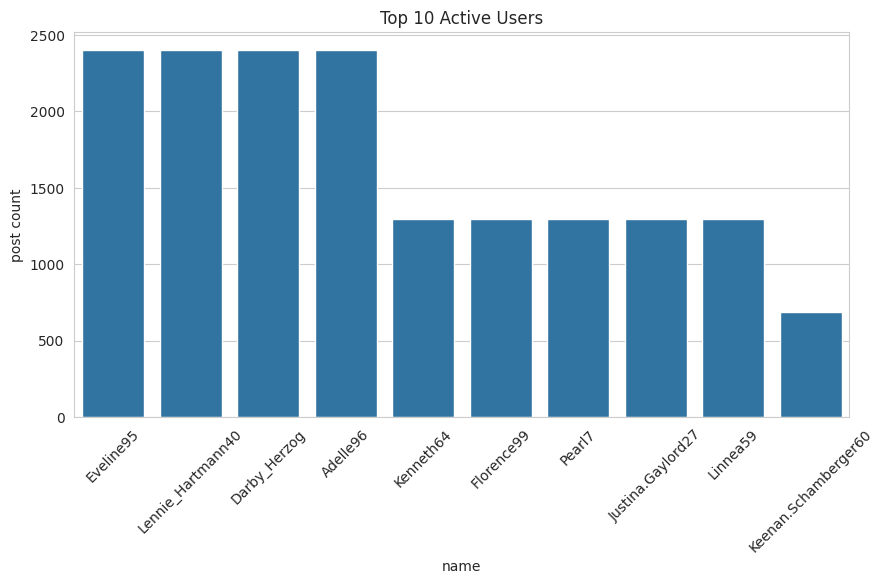

In [42]:
top_users = users.sort_values("post count", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x="name", y="post count", data=top_users)

plt.xticks(rotation=45)
plt.title("Top 10 Active Users")
plt.show()

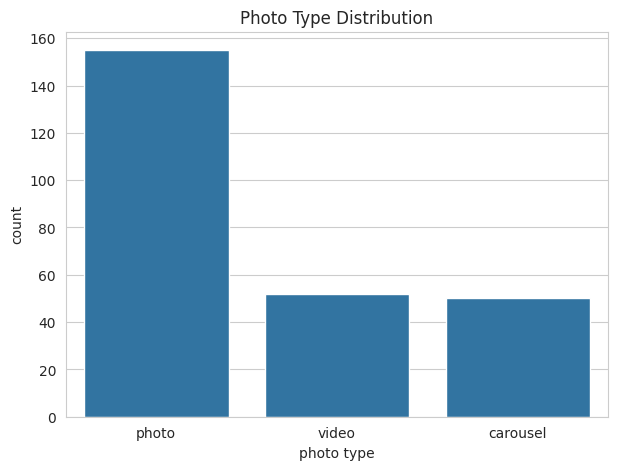

In [43]:
plt.figure(figsize=(7,5))

sns.countplot(x="photo type", data=photos)

plt.title("Photo Type Distribution")
plt.show()

In [44]:
likes_per_photo = likes.groupby("photo").size().reset_index(name="Total Likes")

likes_per_photo.head()

,photo,Total Likes
0,1,25
1,2,36
2,3,38
3,4,38
4,5,31


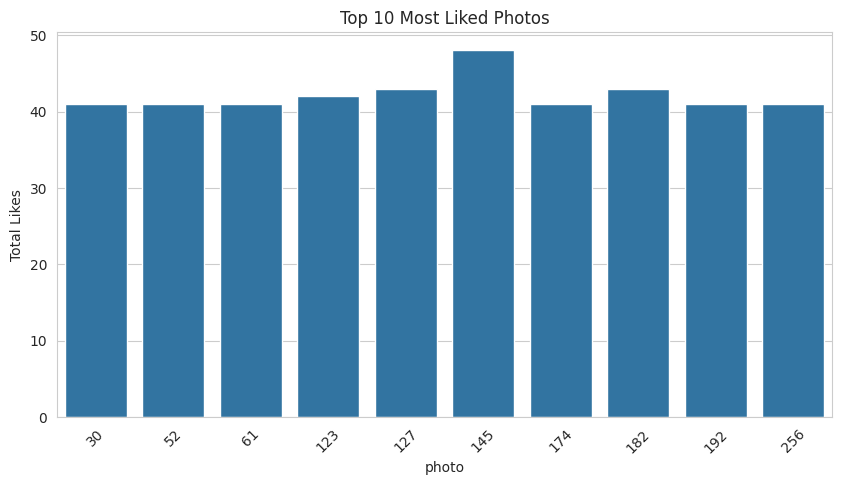

In [45]:
top_likes = likes_per_photo.sort_values("Total Likes", ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x="photo", y="Total Likes", data=top_likes)

plt.title("Top 10 Most Liked Photos")

plt.xticks(rotation=45)

plt.show()

In [46]:
comments_per_photo = comments.groupby("Photo id").size().reset_index(name="Total Comments")

comments_per_photo.head()

,Photo id,Total Comments
0,1,25
1,2,31
2,3,27
3,4,32
4,5,27


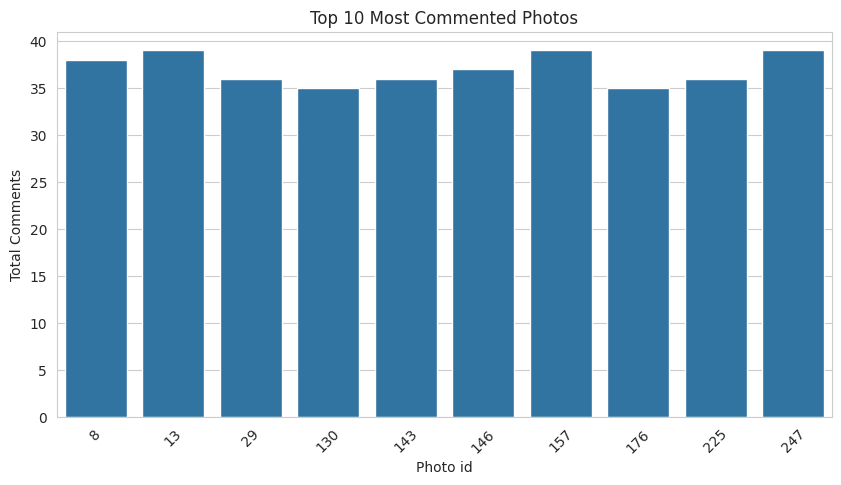

In [47]:
top_comments = comments_per_photo.sort_values("Total Comments", ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x="Photo id", y="Total Comments", data=top_comments)

plt.title("Top 10 Most Commented Photos")

plt.xticks(rotation=45)

plt.show()

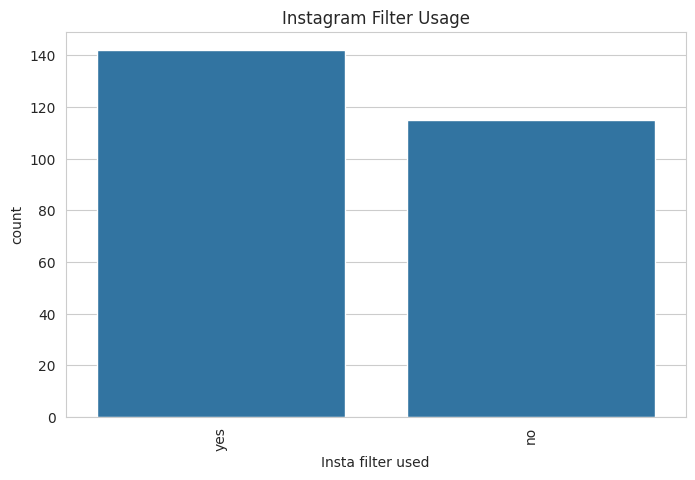

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(data=photos, x="Insta filter used")

plt.xticks(rotation=90)

plt.title("Instagram Filter Usage")

plt.show()

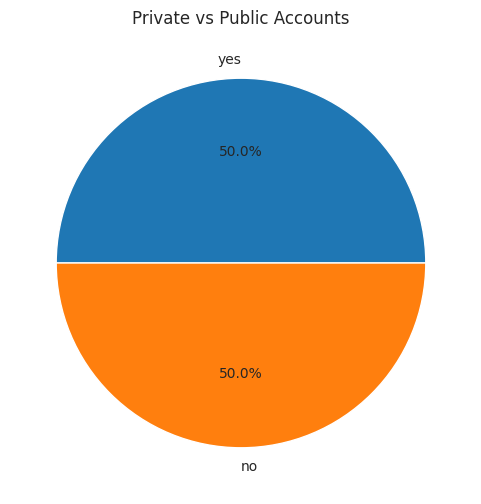

In [49]:
plt.figure(figsize=(6,6))

users["private/public"].value_counts().plot.pie(autopct="%1.1f%%")

plt.ylabel("")

plt.title("Private vs Public Accounts")

plt.show()

plt.figure(figsize=(6,5))

sns.countplot(data=users, x="Verified status")

plt.title("Verified Status")

plt.show()

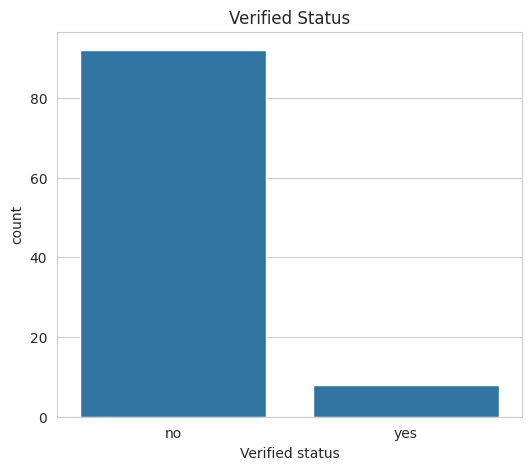

In [50]:
plt.figure(figsize=(6,5))

sns.countplot(data=users, x="Verified status")

plt.title("Verified Status")

plt.show()

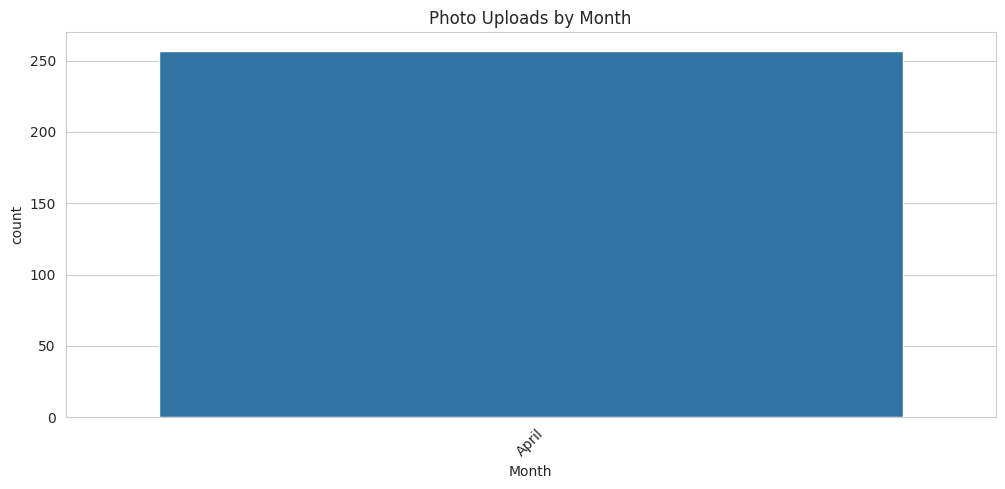

In [51]:
photos["Month"] = photos["created dat"].dt.month_name()

plt.figure(figsize=(12,5))

sns.countplot(data=photos, x="Month")

plt.xticks(rotation=45)

plt.title("Photo Uploads by Month")

plt.show()

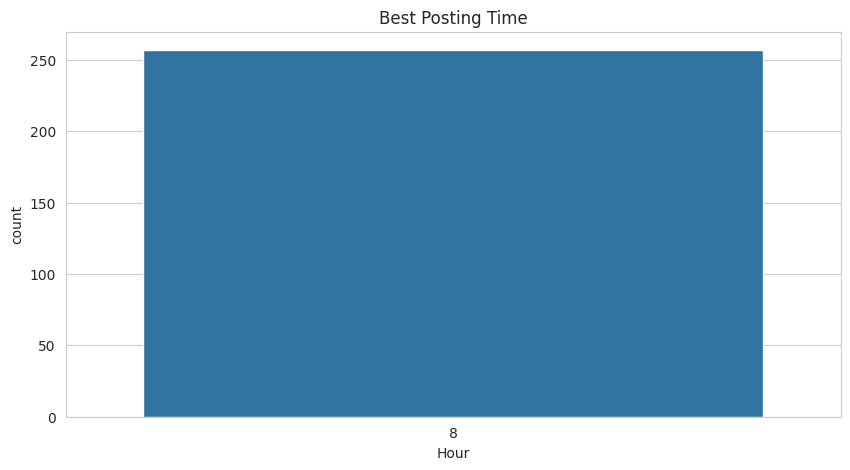

In [52]:
photos["Hour"] = photos["created dat"].dt.hour

plt.figure(figsize=(10,5))

sns.countplot(data=photos, x="Hour")

plt.title("Best Posting Time")

plt.show()

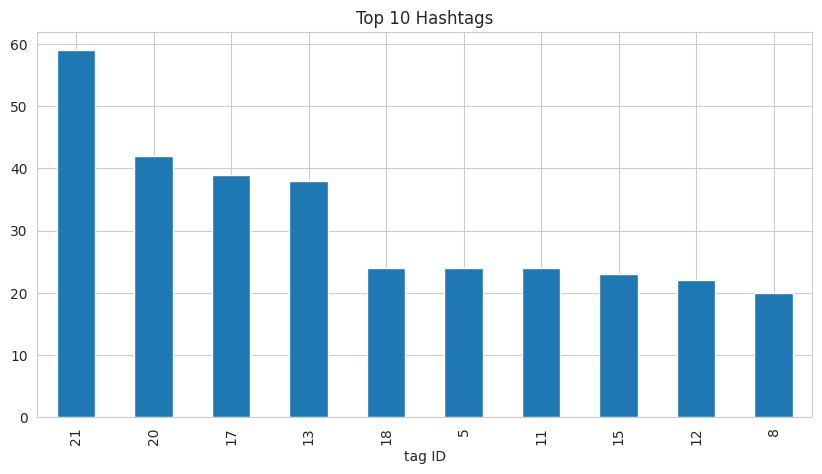

In [53]:
top_tags = photo_tags["tag ID"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_tags.plot(kind="bar")

plt.title("Top 10 Hashtags")

plt.show()

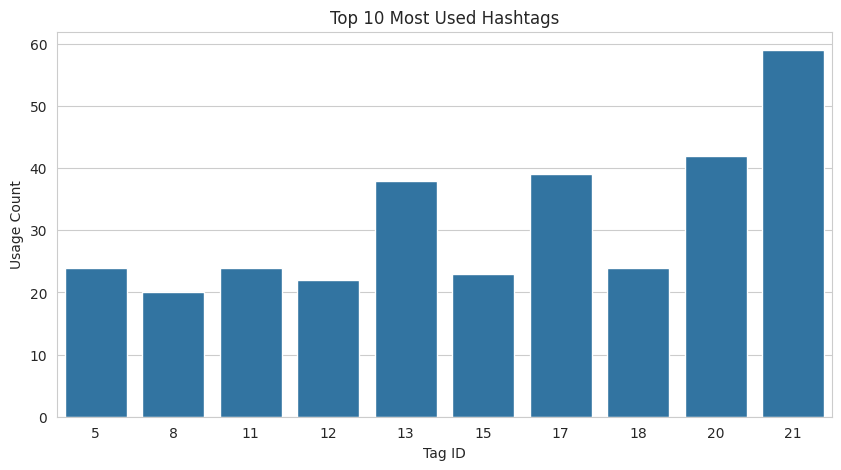

In [54]:
top_tags = photo_tags.groupby("tag ID").size().reset_index(name="Count")

top_tags = top_tags.sort_values("Count", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_tags, x="tag ID", y="Count")

plt.title("Top 10 Most Used Hashtags")
plt.xlabel("Tag ID")
plt.ylabel("Usage Count")
plt.show()

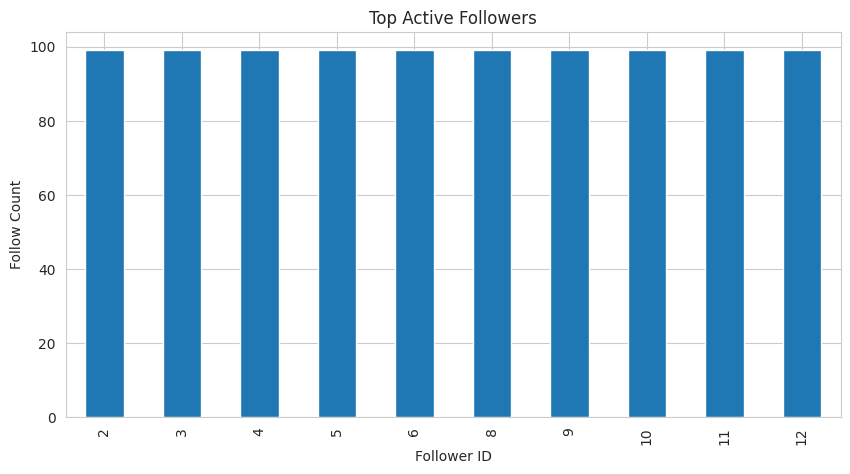

In [55]:
top_followers = follows["follower"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_followers.plot(kind="bar")

plt.title("Top Active Followers")
plt.xlabel("Follower ID")
plt.ylabel("Follow Count")
plt.show()

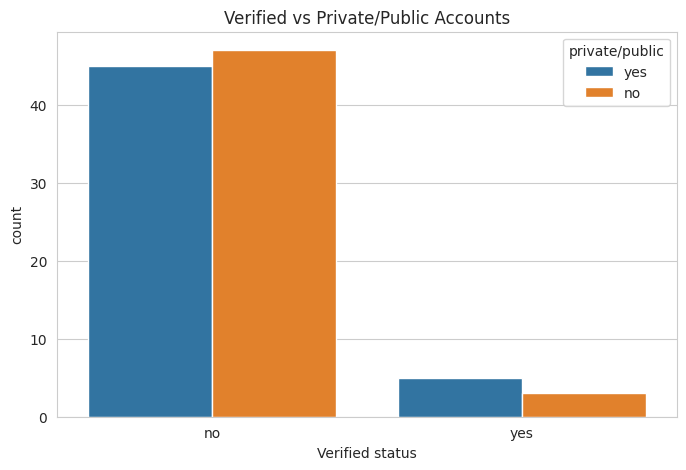

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(data=users,
              x="Verified status",
              hue="private/public")

plt.title("Verified vs Private/Public Accounts")

plt.show()

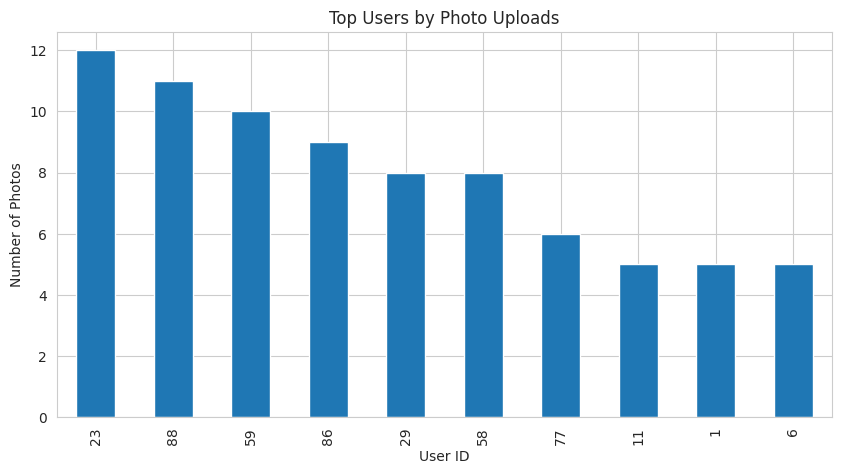

In [57]:
photo_count = photos["user ID"].value_counts().head(10)

plt.figure(figsize=(10,5))
photo_count.plot(kind="bar")

plt.title("Top Users by Photo Uploads")

plt.xlabel("User ID")

plt.ylabel("Number of Photos")

plt.show()

In [58]:
print("Total Users :", len(users))
print("Total Photos :", len(photos))
print("Total Likes :", len(likes))
print("Total Comments :", len(comments))
print("Total Follows :", len(follows))
print("Total Tags :", len(tags))

Total Users : 100
Total Photos : 257
Total Likes : 8782
Total Comments : 7488
Total Follows : 7623
Total Tags : 21


In [59]:
print("""
KEY INSIGHTS

1. Photo posts are more common than videos and carousel posts.

2. A few users contribute the highest number of posts.

3. Some hashtags are used much more frequently than others.

4. User engagement mainly depends on likes, comments, and posting activity.

5. Verified and public accounts generally have higher visibility.
""")


KEY INSIGHTS

1. Photo posts are more common than videos and carousel posts.

2. A few users contribute the highest number of posts.

3. Some hashtags are used much more frequently than others.

4. User engagement mainly depends on likes, comments, and posting activity.

5. Verified and public accounts generally have higher visibility.



In [60]:
print("""
BUSINESS RECOMMENDATIONS

1. Post more photo and carousel content.

2. Publish content during peak engagement hours.

3. Use trending hashtags consistently.

4. Encourage comments through interactive captions.

5. Maintain a regular posting schedule for better audience growth.
""")


BUSINESS RECOMMENDATIONS

1. Post more photo and carousel content.

2. Publish content during peak engagement hours.

3. Use trending hashtags consistently.

4. Encourage comments through interactive captions.

5. Maintain a regular posting schedule for better audience growth.



In [61]:
print("""
CONCLUSION

This project analyzed Instagram user activity, photos, likes,
comments, follows, and hashtags.
The analysis helped identify user engagement patterns,
popular content types, and hashtag usage.
The insights can help Alfido Tech improve its Instagram
marketing strategy and increase audience engagement.
""")


CONCLUSION

This project analyzed Instagram user activity, photos, likes,
comments, follows, and hashtags.
The analysis helped identify user engagement patterns,
popular content types, and hashtag usage.
The insights can help Alfido Tech improve its Instagram
marketing strategy and increase audience engagement.

